# C03 — Classifier-Based Bias Audit of LLM-Generated Narratives

**Question**: Do LLMs perpetuate, accentuate, or suppress the racial linguistic register found in real police use-of-force reports?

**Method**: Use fine-tuned classifiers (DeBERTa-v3-small, BERT-base-uncased) trained on *real* narratives as a bias meter.
Apply them to 14,037 LLM-generated narratives conditioned on Black or White subjects.
If `P(Black)` is systematically higher for Black-conditioned generations (within matched pairs),
the LLM is replicating the same racial register present in human-authored reports.

**Models audited**: GPT-4o, Claude Sonnet, DeepSeek-V3, Gemini Flash, Mistral-Large, Gemma3-27b, LLaMA-3.1-70b, Mistral-Small  
**Conditions**: Zero-shot, Few-shot  
**Classifiers**: DeBERTa-v3-small (BA=0.582 on real narratives), BERT-base-uncased

**Key metrics**:
- Balanced accuracy on generated narratives (race condition = ground truth)
- Mean `P(Black)` gap: Black-conditioned minus White-conditioned within matched pairs
- Per-model and per-condition breakdown
- FDR-corrected paired t-tests

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import sys
sys.path.insert(0, '../../notebooks')
sys.path.insert(0, '../../notebooks/classification')
import config

import json
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 32
MAX_LEN = 256
print(f'Device: {device}')
print(f'Batch size: {BATCH_SIZE}')

Device: cuda
Batch size: 32


## 1. Load Trained Classifiers

We load the best checkpoint for each model (seed=42, selected by validation balanced accuracy).
Models are loaded in eval mode; no further training occurs.

In [2]:
import glob as _glob

def find_best_checkpoint(model_dir):
    """Return best_model_checkpoint from trainer_state.json in the most recent checkpoint dir."""
    chkpts = sorted(
        _glob.glob(os.path.join(model_dir, 'checkpoint-*')),
        key=os.path.getmtime
    )
    for chkpt in reversed(chkpts):
        state_file = os.path.join(chkpt, 'trainer_state.json')
        if os.path.exists(state_file):
            with open(state_file) as f:
                state = json.load(f)
            best = state.get('best_model_checkpoint')
            if best and os.path.exists(best):
                return best, state.get('best_metric')
    return model_dir, None


def load_classifier(model_name, model_dir_name):
    """Load a fine-tuned classifier from its best checkpoint."""
    model_dir = os.path.join(config.BERT_DIR, model_dir_name)
    best_ckpt, best_metric = find_best_checkpoint(model_dir)
    print(f'  {model_dir_name}: loading from {best_ckpt}  (val BA={best_metric:.4f})')

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForSequenceClassification.from_pretrained(
        best_ckpt,
        num_labels=2,
        id2label={0: 'White', 1: 'Black'},
        label2id={'White': 0, 'Black': 1},
        torch_dtype=torch.float32,
        ignore_mismatched_sizes=True,
    ).to(device)
    model.eval()
    return tokenizer, model


CLASSIFIERS = {
    'deberta-v3-small': ('microsoft/deberta-v3-small', 'deberta-v3-small_seed42'),
    'bert-base-uncased': ('bert-base-uncased',         'bert-base-uncased_seed42'),
}

loaded_classifiers = {}
for clf_key, (model_name, dir_name) in CLASSIFIERS.items():
    print(f'Loading {clf_key} ...')
    tok, mdl = load_classifier(model_name, dir_name)
    loaded_classifiers[clf_key] = {'tokenizer': tok, 'model': mdl}
    print(f'  OK')

print('\nAll classifiers loaded.')

Loading deberta-v3-small ...
  deberta-v3-small_seed42: loading from ../../models/bert/deberta-v3-small_seed42/checkpoint-284  (val BA=0.5993)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

  OK
Loading bert-base-uncased ...
  bert-base-uncased_seed42: loading from ../../models/bert/bert-base-uncased_seed42/checkpoint-284  (val BA=0.6560)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  OK

All classifiers loaded.


## 2. Load Generated Narratives

In [3]:
GEN_PATH = os.path.join(config.PIPELINE_OUT, 'generation_v2.jsonl')

records = []
with open(GEN_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

gen_df = pd.DataFrame(records)
gen_df['label'] = (gen_df['race'] == 'Black').astype(int)  # 1=Black, 0=White

# Drop rows with missing or empty generated text
gen_df = gen_df[gen_df['generated_text'].notna()]
gen_df = gen_df[gen_df['generated_text'].str.strip().str.len() > 10].copy()
gen_df = gen_df.reset_index(drop=True)

print(f'Total narratives: {len(gen_df)}')
print(f'Race: {gen_df["race"].value_counts().to_dict()}')
print(f'Models: {sorted(gen_df["model"].unique())}')
print(f'Conditions: {gen_df["condition"].unique().tolist()}')
print(f'Pair IDs: {gen_df["pair_id"].nunique()}')

Total narratives: 14021
Race: {'Black': 7011, 'White': 7010}
Models: ['claude-sonnet', 'deepseek-v3', 'gemini-3-flash', 'gemma3-27b', 'gpt-5.4', 'llama3.1-70b', 'mistral-large', 'mistral-small3.2']
Conditions: ['zeroshot', 'fewshot']
Pair IDs: 500


## 3. Batch Inference

For each classifier, run all generated narratives through the model and collect:
- `pred_label`: argmax prediction (0=White, 1=Black)
- `p_black`: softmax probability for the Black class

Results are saved to disk after each classifier to avoid recomputation.

In [4]:
import gc

AUDIT_OUT = os.path.join(config.CLASS_OUT, 'classifier_bias_audit_results.json')

def batch_predict(texts, tokenizer, model, batch_size=BATCH_SIZE, max_len=MAX_LEN):
    """Return (pred_labels, p_black) arrays for a list of texts."""
    all_preds, all_p_black = [], []
    model.eval()
    for i in range(0, len(texts), batch_size):
        batch = texts[i: i + batch_size]
        enc = tokenizer(
            batch, truncation=True, max_length=max_len,
            padding='max_length', return_tensors='pt'
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            logits = model(**enc).logits          # (B, 2)
        probs = F.softmax(logits.float(), dim=-1).cpu().numpy()   # (B, 2)
        all_preds.extend(probs.argmax(axis=1).tolist())
        all_p_black.extend(probs[:, 1].tolist())  # col 1 = Black
    return np.array(all_preds), np.array(all_p_black)


texts = gen_df['generated_text'].tolist()
true_labels = gen_df['label'].tolist()

audit_results = {}   # clf_key -> {pred_labels, p_black}

for clf_key, clf in loaded_classifiers.items():
    print(f'\nRunning inference: {clf_key}  ({len(texts)} narratives) ...')
    preds, p_black = batch_predict(texts, clf['tokenizer'], clf['model'])
    audit_results[clf_key] = {
        'pred_labels': preds.tolist(),
        'p_black':     p_black.tolist(),
    }
    ba = balanced_accuracy_score(true_labels, preds)
    f1 = f1_score(true_labels, preds, average='macro')
    print(f'  Overall BA={ba:.4f}  F1={f1:.4f}')
    print(classification_report(true_labels, preds, target_names=['White', 'Black']))
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Attach predictions to the dataframe
for clf_key in audit_results:
    gen_df[f'pred_{clf_key}']    = audit_results[clf_key]['pred_labels']
    gen_df[f'p_black_{clf_key}'] = audit_results[clf_key]['p_black']

# Save raw predictions
save_payload = {
    clf_key: {
        'pred_labels': audit_results[clf_key]['pred_labels'],
        'p_black':     audit_results[clf_key]['p_black'],
    }
    for clf_key in audit_results
}
with open(AUDIT_OUT, 'w') as f:
    json.dump(save_payload, f)
print(f'\nPredictions saved to {AUDIT_OUT}')


Running inference: deberta-v3-small  (14021 narratives) ...
  Overall BA=0.4995  F1=0.4991
              precision    recall  f1-score   support

       White       0.50      0.53      0.51      7010
       Black       0.50      0.47      0.48      7011

    accuracy                           0.50     14021
   macro avg       0.50      0.50      0.50     14021
weighted avg       0.50      0.50      0.50     14021


Running inference: bert-base-uncased  (14021 narratives) ...
  Overall BA=0.4915  F1=0.4912
              precision    recall  f1-score   support

       White       0.49      0.47      0.48      7010
       Black       0.49      0.52      0.50      7011

    accuracy                           0.49     14021
   macro avg       0.49      0.49      0.49     14021
weighted avg       0.49      0.49      0.49     14021


Predictions saved to ../../outputs/classification/classifier_bias_audit_results.json


## 4. Analysis 1 — Overall Classification Accuracy on Generated Narratives

Balanced accuracy above 0.5 indicates that the classifier can distinguish Black-conditioned from
White-conditioned generated text — i.e., the LLMs collectively replicate the racial register
present in real police reports.

In [5]:
from scipy.stats import ttest_1samp, ttest_rel

print('=' * 65)
print(f'  Overall classifier performance on LLM-generated narratives')
print('=' * 65)

overall_rows = []
for clf_key in audit_results:
    preds    = np.array(audit_results[clf_key]['pred_labels'])
    p_black  = np.array(audit_results[clf_key]['p_black'])
    labels   = np.array(true_labels)

    ba      = balanced_accuracy_score(labels, preds)
    f1      = f1_score(labels, preds, average='macro')
    report  = classification_report(labels, preds, target_names=['White','Black'], output_dict=True)
    white_r = report['White']['recall']
    black_r = report['Black']['recall']

    # Mean P(Black) by race condition
    mean_p_black_black = p_black[labels == 1].mean()
    mean_p_black_white = p_black[labels == 0].mean()
    gap = mean_p_black_black - mean_p_black_white

    # One-sample t-test: is BA > 0.5?
    # Approximate via a binomial test on predictions
    from scipy.stats import binom_test
    n_correct = (preds == labels).sum()
    binom_p = binom_test(n_correct, len(labels), p=0.5, alternative='greater')

    print(f'\n  {clf_key}')
    print(f'    BA={ba:.4f}  F1={f1:.4f}  (binom p-vs-chance={binom_p:.4e})')
    print(f'    White-R={white_r:.3f}  Black-R={black_r:.3f}')
    print(f'    Mean P(Black) | Black-cond={mean_p_black_black:.4f}  White-cond={mean_p_black_white:.4f}  gap={gap:+.4f}')

    overall_rows.append({
        'classifier': clf_key,
        'BA': ba, 'F1': f1,
        'White_recall': white_r, 'Black_recall': black_r,
        'mean_p_black_BLACK': mean_p_black_black,
        'mean_p_black_WHITE': mean_p_black_white,
        'p_black_gap': gap,
        'binom_p': binom_p,
    })

overall_df = pd.DataFrame(overall_rows)
print('\n', overall_df.to_string(index=False))

  Overall classifier performance on LLM-generated narratives

  deberta-v3-small
    BA=0.4995  F1=0.4991  (binom p-vs-chance=5.5374e-01)
    White-R=0.528  Black-R=0.471
    Mean P(Black) | Black-cond=0.4808  White-cond=0.4781  gap=+0.0027

  bert-base-uncased
    BA=0.4915  F1=0.4912  (binom p-vs-chance=9.7866e-01)
    White-R=0.467  Black-R=0.516
    Mean P(Black) | Black-cond=0.5235  White-cond=0.5310  gap=-0.0075

        classifier       BA       F1  White_recall  Black_recall  mean_p_black_BLACK  mean_p_black_WHITE  p_black_gap  binom_p
 deberta-v3-small 0.499467 0.499063      0.527817      0.471117            0.480796            0.478070     0.002726 0.553743
bert-base-uncased 0.491475 0.491165      0.466762      0.516189            0.523528            0.531025    -0.007498 0.978663


## 5. Analysis 2 — Per-LLM Bias Score

For each LLM, compute:
1. Balanced accuracy (race condition = ground truth)
2. Mean `P(Black)` gap (Black-conditioned minus White-conditioned)
3. Within-pair paired t-test on `P(Black)` for matched pairs (same `pair_id`, same `condition`)

All p-values are corrected for multiple comparisons using the Benjamini-Hochberg FDR procedure.

In [6]:
from statsmodels.stats.multitest import multipletests

models_list = sorted(gen_df['model'].unique())

per_model_rows = []

for clf_key in audit_results:
    p_black_col = f'p_black_{clf_key}'
    pred_col    = f'pred_{clf_key}'

    print(f'\n{"-"*65}')
    print(f'  Classifier: {clf_key}')
    print(f'{"-"*65}')
    print(f'  {"Model":<22} {"BA":>6} {"F1":>6} {"W-R":>6} {"B-R":>6} {"Gap":>8} {"p-value":>10}')
    print(f'  {"-"*70}')

    raw_pvals = []
    model_stats = []

    for llm in models_list:
        sub = gen_df[gen_df['model'] == llm].copy()

        labels_sub = sub['label'].values
        preds_sub  = sub[pred_col].values
        pblack_sub = sub[p_black_col].values

        ba      = balanced_accuracy_score(labels_sub, preds_sub)
        f1      = f1_score(labels_sub, preds_sub, average='macro')
        report  = classification_report(labels_sub, preds_sub, target_names=['White','Black'], output_dict=True)
        white_r = report['White']['recall']
        black_r = report['Black']['recall']

        # Within-pair paired t-test: match on pair_id + condition
        black_sub = sub[sub['race'] == 'Black'][['pair_id','condition', p_black_col]].rename(columns={p_black_col: 'pb_black'})
        white_sub = sub[sub['race'] == 'White'][['pair_id','condition', p_black_col]].rename(columns={p_black_col: 'pb_white'})
        paired = black_sub.merge(white_sub, on=['pair_id','condition'], how='inner')

        if len(paired) >= 5:
            t_stat, p_val = stats.ttest_rel(paired['pb_black'], paired['pb_white'])
            gap = (paired['pb_black'] - paired['pb_white']).mean()
        else:
            t_stat, p_val, gap = np.nan, np.nan, np.nan

        raw_pvals.append(p_val)
        model_stats.append({
            'classifier': clf_key, 'model': llm,
            'BA': ba, 'F1': f1,
            'White_recall': white_r, 'Black_recall': black_r,
            'p_black_gap': gap, 'p_val': p_val, 'n_pairs': len(paired),
        })

    # FDR correction
    valid_mask = [not np.isnan(p) for p in raw_pvals]
    valid_pvals = [p for p in raw_pvals if not np.isnan(p)]
    if valid_pvals:
        _, q_vals, _, _ = multipletests(valid_pvals, method='fdr_bh')
    q_iter = iter(q_vals if valid_pvals else [])

    for i, row in enumerate(model_stats):
        row['q_val'] = next(q_iter) if valid_mask[i] else np.nan
        sig = '***' if row['q_val'] < 0.001 else ('**' if row['q_val'] < 0.01 else ('*' if row['q_val'] < 0.05 else 'n.s.'))
        print(f"  {row['model']:<22} {row['BA']:>6.3f} {row['F1']:>6.3f} {row['White_recall']:>6.3f} {row['Black_recall']:>6.3f} {row['p_black_gap']:>+8.4f} {row['p_val']:>10.4e} {sig}")
        per_model_rows.append(row)

per_model_df = pd.DataFrame(per_model_rows)

# Save
per_model_out = os.path.join(config.CLASS_OUT, 'classifier_bias_audit_per_model.json')
per_model_df.to_json(per_model_out, orient='records', indent=2)
print(f'\nPer-model results saved to {per_model_out}')


-----------------------------------------------------------------
  Classifier: deberta-v3-small
-----------------------------------------------------------------
  Model                      BA     F1    W-R    B-R      Gap    p-value
  ----------------------------------------------------------------------
  claude-sonnet           0.495  0.494  0.452  0.538  +0.0009 8.5954e-01 n.s.
  deepseek-v3             0.500  0.493  0.614  0.386  +0.0016 7.6783e-01 n.s.
  gemini-3-flash          0.512  0.494  0.703  0.322  +0.0079 1.6761e-01 n.s.
  gemma3-27b              0.493  0.474  0.300  0.686  -0.0077 1.6272e-01 n.s.
  gpt-5.4                 0.513  0.511  0.452  0.574  +0.0110 7.4685e-02 n.s.
  llama3.1-70b            0.482  0.476  0.593  0.371  +0.0004 9.4810e-01 n.s.
  mistral-large           0.496  0.495  0.447  0.545  +0.0095 3.9900e-02 n.s.
  mistral-small3.2        0.495  0.483  0.648  0.341  -0.0075 2.7877e-01 n.s.

-----------------------------------------------------------------

## 6. Analysis 3 — Zero-Shot vs Few-Shot

Does providing in-context examples (few-shot) amplify or suppress the racial register?

In [7]:
condition_rows = []

for clf_key in audit_results:
    p_black_col = f'p_black_{clf_key}'
    pred_col    = f'pred_{clf_key}'

    print(f'\nClassifier: {clf_key}')
    print(f'  {"Condition":<12} {"BA":>6} {"F1":>6} {"Gap":>8} {"p-value":>10}')

    for cond in ['zeroshot', 'fewshot']:
        sub = gen_df[gen_df['condition'] == cond].copy()
        if len(sub) == 0:
            continue

        labels_sub = sub['label'].values
        preds_sub  = sub[pred_col].values
        pblack_sub = sub[p_black_col].values

        ba = balanced_accuracy_score(labels_sub, preds_sub)
        f1 = f1_score(labels_sub, preds_sub, average='macro')

        black_sub = sub[sub['race'] == 'Black'][['pair_id','model', p_black_col]].rename(columns={p_black_col: 'pb_black'})
        white_sub = sub[sub['race'] == 'White'][['pair_id','model', p_black_col]].rename(columns={p_black_col: 'pb_white'})
        paired = black_sub.merge(white_sub, on=['pair_id','model'], how='inner')

        if len(paired) >= 5:
            _, p_val = stats.ttest_rel(paired['pb_black'], paired['pb_white'])
            gap = (paired['pb_black'] - paired['pb_white']).mean()
        else:
            p_val, gap = np.nan, np.nan

        sig = '***' if (p_val is not None and p_val < 0.001) else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'n.s.'))
        print(f'  {cond:<12} {ba:>6.3f} {f1:>6.3f} {gap:>+8.4f} {p_val:>10.4e} {sig}')

        condition_rows.append({
            'classifier': clf_key, 'condition': cond,
            'BA': ba, 'F1': f1, 'gap': gap, 'p_val': p_val,
        })

    # Cross-condition test: is BA/gap significantly different between zero-shot and few-shot?
    zs = gen_df[gen_df['condition'] == 'zeroshot']
    fs = gen_df[gen_df['condition'] == 'fewshot']
    if len(zs) > 0 and len(fs) > 0:
        zs_gap = (zs[zs['race']=='Black'][p_black_col].values.mean() -
                  zs[zs['race']=='White'][p_black_col].values.mean())
        fs_gap = (fs[fs['race']=='Black'][p_black_col].values.mean() -
                  fs[fs['race']=='White'][p_black_col].values.mean())
        print(f'  Zero-shot gap={zs_gap:+.4f}  Few-shot gap={fs_gap:+.4f}  delta={fs_gap - zs_gap:+.4f}')


Classifier: deberta-v3-small
  Condition        BA     F1      Gap    p-value
  zeroshot      0.495  0.494  -0.0022 4.3336e-01 n.s.
  fewshot       0.504  0.500  +0.0081 4.7518e-03 **
  Zero-shot gap=-0.0027  Few-shot gap=+0.0081  delta=+0.0108

Classifier: bert-base-uncased
  Condition        BA     F1      Gap    p-value
  zeroshot      0.494  0.494  -0.0075 1.2043e-01 n.s.
  fewshot       0.489  0.489  -0.0071 1.6314e-01 n.s.
  Zero-shot gap=-0.0079  Few-shot gap=-0.0071  delta=+0.0009


## 7. Analysis 4 — Model Ranking by Bias Perpetuation

We rank LLMs by the magnitude of the mean `P(Black)` gap (larger gap = stronger replication of real-narrative bias).
We also report which direction the bias runs: higher `P(Black)` for Black-conditioned text (perpetuation) or
the reverse (inversion), or no significant difference (neutral).

In [8]:
for clf_key in audit_results:
    sub_df = per_model_df[per_model_df['classifier'] == clf_key].copy()
    sub_df['abs_gap'] = sub_df['p_black_gap'].abs()
    sub_df = sub_df.sort_values('abs_gap', ascending=False)

    print(f'\nRanking by |P(Black) gap| — classifier: {clf_key}')
    print(f'  {"Rank":<5} {"Model":<22} {"Gap":>8} {"Direction":<15} {"q-val":>10}')
    print(f'  {"-"*65}')

    for rank, (_, row) in enumerate(sub_df.iterrows(), 1):
        if row['q_val'] < 0.05:
            direction = 'perpetuates' if row['p_black_gap'] > 0 else 'inverts'
        else:
            direction = 'neutral'
        sig = '***' if row['q_val'] < 0.001 else ('**' if row['q_val'] < 0.01 else ('*' if row['q_val'] < 0.05 else 'n.s.'))
        print(f"  {rank:<5} {row['model']:<22} {row['p_black_gap']:>+8.4f} {direction:<15} {row['q_val']:>10.4e} {sig}")


Ranking by |P(Black) gap| — classifier: deberta-v3-small
  Rank  Model                       Gap Direction            q-val
  -----------------------------------------------------------------
  1     gpt-5.4                 +0.0110 neutral         2.9874e-01 n.s.
  2     mistral-large           +0.0095 neutral         2.9874e-01 n.s.
  3     gemini-3-flash          +0.0079 neutral         3.3522e-01 n.s.
  4     gemma3-27b              -0.0077 neutral         3.3522e-01 n.s.
  5     mistral-small3.2        -0.0075 neutral         4.4603e-01 n.s.
  6     deepseek-v3             +0.0016 neutral         9.4810e-01 n.s.
  7     claude-sonnet           +0.0009 neutral         9.4810e-01 n.s.
  8     llama3.1-70b            +0.0004 neutral         9.4810e-01 n.s.

Ranking by |P(Black) gap| — classifier: bert-base-uncased
  Rank  Model                       Gap Direction            q-val
  -----------------------------------------------------------------
  1     claude-sonnet           -0.04

## 8. Visualization

Two plots:
1. **Violin plot**: distribution of `P(Black)` by race condition and LLM, for each classifier.
2. **Bar chart**: mean `P(Black)` gap per LLM, sorted by magnitude.

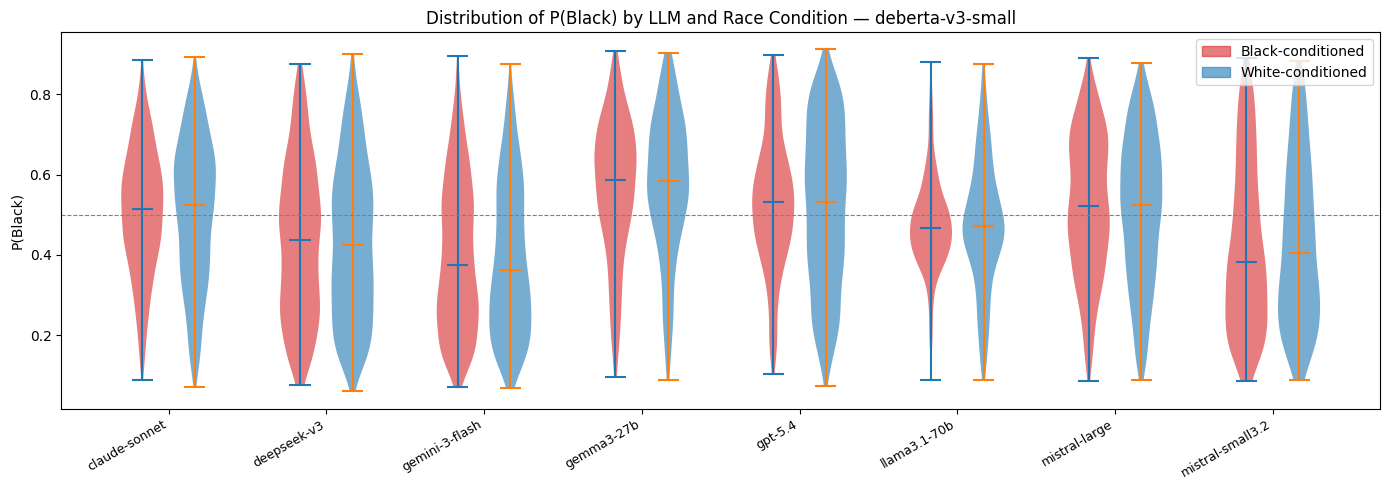

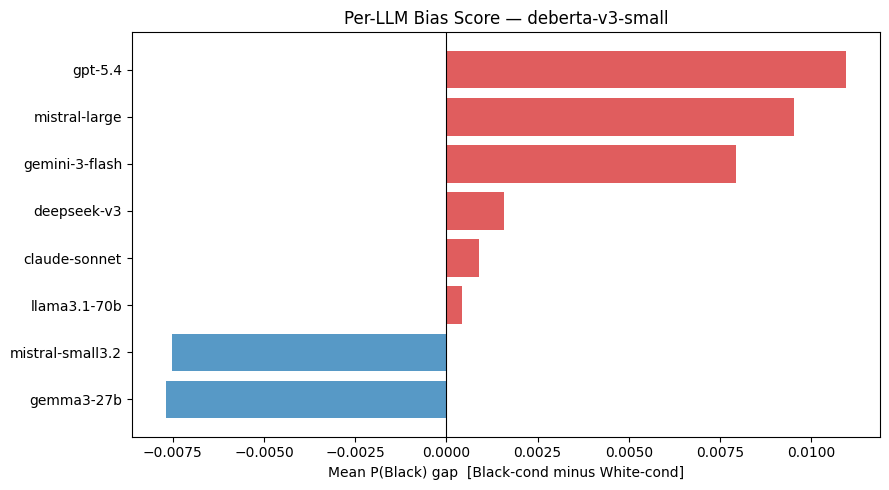

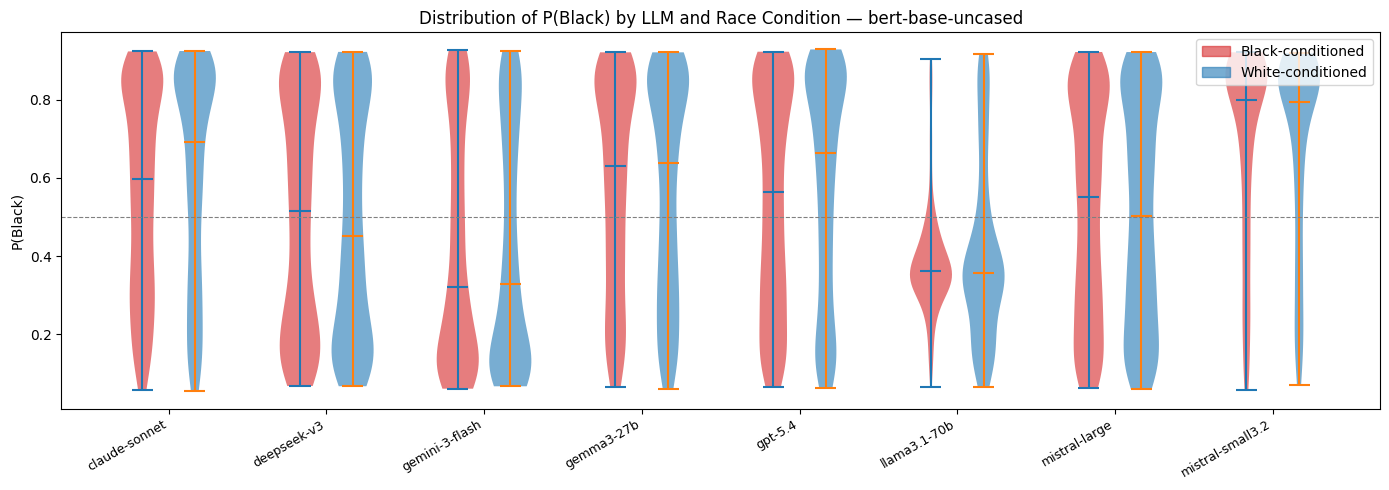

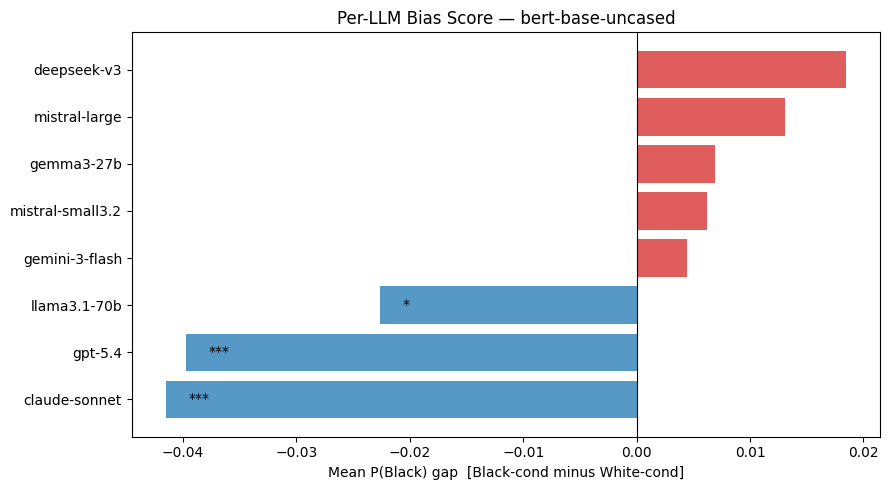

Figures saved.


In [9]:
fig_dir = os.path.join(config.FIGURES_DIR if hasattr(config, 'FIGURES_DIR') else
                        os.path.join(os.path.dirname(config.CLASS_OUT), 'figures'), '')
os.makedirs(fig_dir, exist_ok=True)

for clf_key in audit_results:
    p_black_col = f'p_black_{clf_key}'

    # --- Plot 1: Violin of P(Black) by model and race condition ---
    fig, ax = plt.subplots(figsize=(14, 5))

    positions_black, positions_white = [], []
    data_black,       data_white      = [], []
    xlabels = []

    for i, llm in enumerate(models_list):
        sub = gen_df[gen_df['model'] == llm]
        b   = sub[sub['race'] == 'Black'][p_black_col].values
        w   = sub[sub['race'] == 'White'][p_black_col].values
        x   = i * 3
        positions_black.append(x - 0.5)
        positions_white.append(x + 0.5)
        data_black.append(b)
        data_white.append(w)
        xlabels.append(llm)

    vb = ax.violinplot(data_black, positions=positions_black, widths=0.8, showmedians=True)
    vw = ax.violinplot(data_white, positions=positions_white, widths=0.8, showmedians=True)
    for pc in vb['bodies']: pc.set_facecolor('#d62728'); pc.set_alpha(0.6)
    for pc in vw['bodies']: pc.set_facecolor('#1f77b4'); pc.set_alpha(0.6)

    ax.set_xticks([i * 3 for i in range(len(models_list))])
    ax.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=9)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Chance')
    ax.set_ylabel('P(Black)')
    ax.set_title(f'Distribution of P(Black) by LLM and Race Condition — {clf_key}')
    black_patch = mpatches.Patch(color='#d62728', alpha=0.6, label='Black-conditioned')
    white_patch = mpatches.Patch(color='#1f77b4', alpha=0.6, label='White-conditioned')
    ax.legend(handles=[black_patch, white_patch], loc='upper right')
    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, f'bias_audit_violin_{clf_key}.png'), dpi=150)
    plt.show()

    # --- Plot 2: Bar chart of P(Black) gap per model ---
    sub_df = per_model_df[per_model_df['classifier'] == clf_key].copy()
    sub_df = sub_df.sort_values('p_black_gap', ascending=True)

    fig2, ax2 = plt.subplots(figsize=(9, 5))
    colors = ['#d62728' if g > 0 else '#1f77b4' for g in sub_df['p_black_gap']]
    bars = ax2.barh(sub_df['model'], sub_df['p_black_gap'], color=colors, alpha=0.75)

    # Significance annotations
    for bar, (_, row) in zip(bars, sub_df.iterrows()):
        sig = '***' if row['q_val'] < 0.001 else ('**' if row['q_val'] < 0.01 else ('*' if row['q_val'] < 0.05 else ''))
        if sig:
            ax2.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                     sig, va='center', fontsize=10)

    ax2.axvline(0, color='black', linewidth=0.8)
    ax2.set_xlabel('Mean P(Black) gap  [Black-cond minus White-cond]')
    ax2.set_title(f'Per-LLM Bias Score — {clf_key}')
    plt.tight_layout()
    fig2.savefig(os.path.join(fig_dir, f'bias_audit_gap_{clf_key}.png'), dpi=150)
    plt.show()

print('Figures saved.')

## 9. Analysis 5 — Compare Generated vs Real Narrative Classifier Accuracy

We compare the classifier BA on generated narratives against its BA on real narratives (from C00).
If BA on generated text exceeds BA on real text, LLMs are *amplifying* the racial register.
If lower, they are *suppressing* it.

In [10]:
# Load real-narrative results from C00
real_results_path = os.path.join(config.CLASS_OUT, 'classification_results_deberta_mistral.json')
all_models_path   = os.path.join(config.CLASS_OUT, 'classification_results_all_models.json')

real_ba = {}
for path in [real_results_path, all_models_path]:
    if os.path.exists(path):
        with open(path) as f:
            data = json.load(f)
        for key, val in data.get('neural', {}).items():
            if val.get('mean_ba') is not None:
                real_ba[key] = val['mean_ba']

print('Real-narrative BA (from C00):')
for k, v in real_ba.items():
    print(f'  {k}: {v:.4f}')

print('\nGenerated-narrative BA vs Real-narrative BA:')
print(f'  {"Classifier":<22} {"BA (real)":>10} {"BA (generated)":>15} {"Delta":>8}')
print(f'  {"-"*60}')

for clf_key in audit_results:
    preds  = np.array(audit_results[clf_key]['pred_labels'])
    labels = np.array(true_labels)
    ba_gen = balanced_accuracy_score(labels, preds)

    # Try to match clf_key to real results
    ba_real = real_ba.get(clf_key, real_ba.get(clf_key.replace('-', '_'), None))
    if ba_real is None:
        print(f'  {clf_key:<22} {"N/A":>10} {ba_gen:>15.4f}')
    else:
        delta = ba_gen - ba_real
        direction = 'amplifies' if delta > 0.01 else ('suppresses' if delta < -0.01 else 'replicates')
        print(f'  {clf_key:<22} {ba_real:>10.4f} {ba_gen:>15.4f} {delta:>+8.4f}  ({direction})')

Real-narrative BA (from C00):
  deberta-v3-small: 0.5816
  mistral-7b: 0.5366
  bert-base-uncased: 0.6099

Generated-narrative BA vs Real-narrative BA:
  Classifier              BA (real)  BA (generated)    Delta
  ------------------------------------------------------------
  deberta-v3-small           0.5816          0.4995  -0.0821  (suppresses)
  bert-base-uncased          0.6099          0.4915  -0.1185  (suppresses)


## 10. Summary Table

Consolidated results for reporting.

In [12]:
summary_rows = []

for clf_key in audit_results:
    sub_df = per_model_df[per_model_df['classifier'] == clf_key].copy()

    for _, row in sub_df.iterrows():
        sig = '***' if row['q_val'] < 0.001 else ('**' if row['q_val'] < 0.01 else ('*' if row['q_val'] < 0.05 else 'n.s.'))
        summary_rows.append({
            'Classifier':   clf_key,
            'LLM':          row['model'],
            'BA':           f"{row['BA']:.3f}",
            'F1':           f"{row['F1']:.3f}",
            'White-R':      f"{row['White_recall']:.3f}",
            'Black-R':      f"{row['Black_recall']:.3f}",
            'P(B) gap':     f"{row['p_black_gap']:+.4f}",
            'p-value':      f"{row['p_val']:.4e}",
            'q-value':      f"{row['q_val']:.4e}",
            'Sig':          sig,
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# Save as CSV for easy copy-paste into paper
csv_out = os.path.join(config.CLASS_OUT, 'classifier_bias_audit_summary.csv')
summary_df.to_csv(csv_out, index=False)
print(f'\nSummary table saved to {csv_out}')

       Classifier              LLM    BA    F1 White-R Black-R P(B) gap    p-value    q-value  Sig
 deberta-v3-small    claude-sonnet 0.495 0.494   0.452   0.538  +0.0009 8.5954e-01 9.4810e-01 n.s.
 deberta-v3-small      deepseek-v3 0.500 0.493   0.614   0.386  +0.0016 7.6783e-01 9.4810e-01 n.s.
 deberta-v3-small   gemini-3-flash 0.512 0.494   0.703   0.322  +0.0079 1.6761e-01 3.3522e-01 n.s.
 deberta-v3-small       gemma3-27b 0.493 0.474   0.300   0.686  -0.0077 1.6272e-01 3.3522e-01 n.s.
 deberta-v3-small          gpt-5.4 0.513 0.511   0.452   0.574  +0.0110 7.4685e-02 2.9874e-01 n.s.
 deberta-v3-small     llama3.1-70b 0.482 0.476   0.593   0.371  +0.0004 9.4810e-01 9.4810e-01 n.s.
 deberta-v3-small    mistral-large 0.496 0.495   0.447   0.545  +0.0095 3.9900e-02 2.9874e-01 n.s.
 deberta-v3-small mistral-small3.2 0.495 0.483   0.648   0.341  -0.0075 2.7877e-01 4.4603e-01 n.s.
bert-base-uncased    claude-sonnet 0.466 0.456   0.332   0.600  -0.0415 7.0698e-06 5.6558e-05  ***
bert-base-